Test conversion $\frac{dn}{dlog10(M_{200})}(M_{200}) → \frac{dn}{dlog10(M_{500})}(M_{500})$ /
Basé sur Duffy et al. 2008 et conv chat GPT "Mass definition conversion explanation" (04/08/2025)

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import importlib
from scipy.interpolate import UnivariateSpline
from scipy import integrate
from scipy.optimize import root_scalar

import halo_and_cluster_MF as hcmf
import useful_functions as uf


In [63]:
cosmo = Planck18

Calcul classique de la fonction de masse (dn/dlog10(M200))[M200]


In [64]:

params_GSR = [14.13,-3.96,-1.68,0.63] # valeurs moyennes : pour z = 0.1 !
CMF_GSR_func_M200 = hcmf.CMF_MRP(params_GSR[0],params_GSR[1],params_GSR[2],params_GSR[3])
log10_M_Msun_M200 = np.linspace(12.7,15.5,1000) # Les fits desquels sont issus les paramètres sont valables pour des masses comprises entre 10^12.7 et 10^15.5 Msun
M_Msun_200 = 10**log10_M_Msun_M200
log10_M_Msun_M200 = log10_M_Msun_M200.tolist()
CMF_GSR_M200 = CMF_GSR_func_M200(log10_M_Msun_M200)

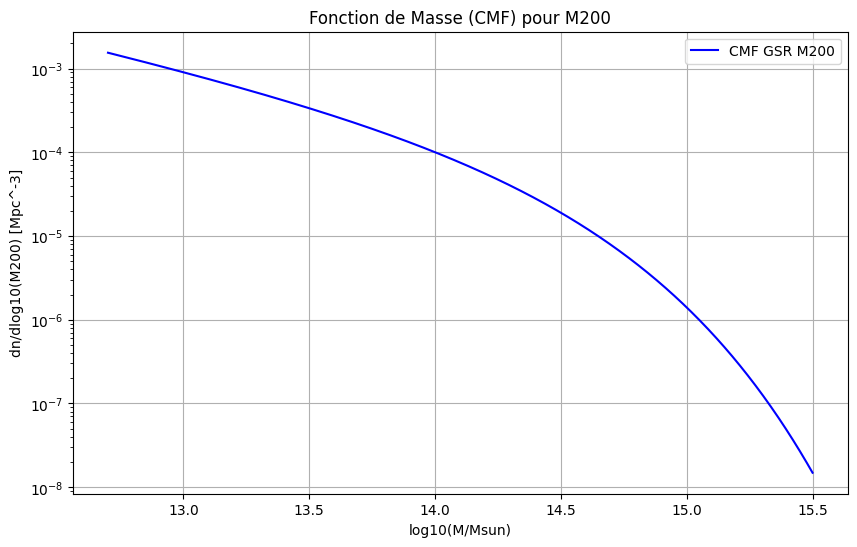

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(log10_M_Msun_M200, CMF_GSR_M200, label='CMF GSR M200', color='blue')
plt.xlabel('log10(M/Msun)')
plt.ylabel('dn/dlog10(M200) [Mpc^-3]')
plt.title('Fonction de Masse (CMF) pour M200')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

Calcul d'un array de log10(M500/Msun) à partir d'un array d'un array de log10(M200/Msun) thanks to Duffy et al. 2008

In [66]:
# Param de concentration Duffy et al. 2008 : Table 1 → Full relaxed NFW profile 

A = 5.71
B = -0.084
C = -0.47
M_pivot = 2*(10**12)*(0.7**(-1))

z_value = 0.1 # Redshift pour lequel on calcule la concentration (pour l'instant on prend z=0.1 car les paramètres GSR sont pour z=0.1)


c_M200 = A * (M_Msun_200 / M_pivot)**B * (1 + z_value)**C

In [67]:
# On calcule les paramètres du profil NFW pour chaque masse
# !!! Pour l'instant z=0.1 tout le temps !!!

# Calcul rs

R200 = (M_Msun_200 / ((4/3) * np.pi * 200 * cosmo.critical_density(z_value).to('Msun/Mpc3').value))**(1/3) # R200 is in Mpc
rs = R200 / c_M200 # rs is in Mpc

In [68]:
# Calcul rho_0
rho_0 = M_Msun_200 / (4 * np.pi * rs**3 * (np.log(1 + c_M200) - (c_M200 / (1 + c_M200))))

In [69]:
z = np.ones(len(M_Msun_200)) * z_value  # On suppose que z=0.1 pour toutes les masses

In [70]:
def M_enclosed(r, rho_0_input, rs_input):
    # Calcule la masse M(r) à l'intérieur d'une sphère de rayon r pour un profil NFW
    x = r / rs_input
    return 4 * np.pi * rho_0_input * rs_input**3 * (np.log(1 + x) - x / (1 + x))

'''def find_R500(rho_0_input, rs_input, z_input):
    # Trouve le rayon R500 pour un profil NFW donné suivant rho_0 et rs
    def func(r):
        for i in range(len(rho_0_input)):
            M = M_enclosed(r, rho_0_input[i], rs_input[i])
            rho_c500 = 500 * cosmo.critical_density(z_input).to('Msun/Mpc3').value
        return (M / ((4/3)*np.pi*r**3)) - rho_c500
    return func  # Retourne le rayon R500 en Mpc'''


'''def find_R500(rho_0_input, rs_input, z_input):
    rho_c500 = 500 * cosmo.critical_density(z_input).to('Msun/Mpc3').value
    def func(r):
        M = M_enclosed(r, rho_0_input, rs_input)
        return M / ((4/3)*np.pi*r**3) - rho_c500
    result = root_scalar(func, bracket=[1e-3, 2*rs_input], method='brentq')
    return result.root'''

"def find_R500(rho_0_input, rs_input, z_input):\n    rho_c500 = 500 * cosmo.critical_density(z_input).to('Msun/Mpc3').value\n    def func(r):\n        M = M_enclosed(r, rho_0_input, rs_input)\n        return M / ((4/3)*np.pi*r**3) - rho_c500\n    result = root_scalar(func, bracket=[1e-3, 2*rs_input], method='brentq')\n    return result.root"

In [71]:
def find_M500(rho_0_input, rs_input, z_input):
    """
    Compute R500 for a single NFW profile (scalar inputs).
    """
    rho_c500 = 500 * cosmo.critical_density(z_input).to('Msun/Mpc3').value
    def func(r):
        M = M_enclosed(r, rho_0_input, rs_input)
        return M / ((4/3)*np.pi*r**3) - rho_c500
    result = root_scalar(func, bracket=[1e-3, 10], method='brentq') # On touve R500 en Mpc
    return M_enclosed(result.root, rho_0_input, rs_input)  # On utilise R500 pour M500 en Msun

In [72]:
M_Msun_500 = [] # En Msun
for i in range(len(M_Msun_200)):
    M500_current = find_M500(rho_0[i], rs[i], z[i])  # Test avec la première masse
    M_Msun_500.append(M500_current)
M_Msun_500 = np.array(M_Msun_500)

Maintenant qu'on dispose des M500 correspondants aux M200 (n'oublions pas qu'on a tout calculé pour un z = 0.1), on va chercher à calculer numériquement  $\frac{dlog10(M_{200})}{dlog10(M_{500})}$ pour pouvoir réaliser notre conversion de fonction de masse

In [73]:
print('log10_M_Msun_M200 = ',log10_M_Msun_M200)
log10_M_Msun_M500 = np.log10(M_Msun_500)
print('log10_M_Msun_M500 = ',log10_M_Msun_M500)

log10_M_Msun_M200 =  [12.7, 12.702802802802802, 12.705605605605605, 12.708408408408408, 12.71121121121121, 12.714014014014014, 12.716816816816817, 12.71961961961962, 12.722422422422422, 12.725225225225225, 12.728028028028028, 12.730830830830831, 12.733633633633634, 12.736436436436435, 12.739239239239238, 12.74204204204204, 12.744844844844843, 12.747647647647646, 12.75045045045045, 12.753253253253252, 12.756056056056055, 12.758858858858858, 12.76166166166166, 12.764464464464464, 12.767267267267266, 12.77007007007007, 12.772872872872872, 12.775675675675675, 12.778478478478478, 12.78128128128128, 12.784084084084084, 12.786886886886887, 12.78968968968969, 12.792492492492492, 12.795295295295295, 12.798098098098098, 12.800900900900901, 12.803703703703704, 12.806506506506507, 12.809309309309308, 12.81211211211211, 12.814914914914914, 12.817717717717716, 12.82052052052052, 12.823323323323322, 12.826126126126125, 12.828928928928928, 12.83173173173173, 12.834534534534534, 12.837337337337337, 12.

In [74]:
# Interpolator: logM200 as a function of logM500
logM200_of_logM500 = interp1d(log10_M_Msun_M500, log10_M_Msun_M200, kind='cubic', fill_value='extrapolate')

In [75]:
def dlogM200_dlogM500(logM500_grid, logM200_func, delta=1e-4):
    deriv = []
    for x in logM500_grid:
        f_plus = logM200_func(x + delta)
        f_minus = logM200_func(x - delta)
        deriv.append((f_plus - f_minus) / (2 * delta))
    return np.array(deriv)

In [76]:
dlogM200_dlogM500(log10_M_Msun_M500, logM200_of_logM500)

array([1.01470743, 1.01471294, 1.01471846, 1.01472397, 1.01472949,
       1.01473501, 1.01474054, 1.01474606, 1.01475159, 1.01475711,
       1.01476264, 1.01476818, 1.01477371, 1.01477925, 1.01478478,
       1.01479032, 1.01479586, 1.01480141, 1.01480695, 1.0148125 ,
       1.01481805, 1.0148236 , 1.01482915, 1.01483471, 1.01484026,
       1.01484582, 1.01485138, 1.01485694, 1.01486251, 1.01486807,
       1.01487364, 1.01487921, 1.01488478, 1.01489035, 1.01489593,
       1.0149015 , 1.01490708, 1.01491266, 1.01491825, 1.01492383,
       1.01492942, 1.01493501, 1.0149406 , 1.01494619, 1.01495178,
       1.01495738, 1.01496298, 1.01496857, 1.01497418, 1.01497978,
       1.01498538, 1.01499099, 1.0149966 , 1.01500221, 1.01500782,
       1.01501344, 1.01501906, 1.01502467, 1.01503029, 1.01503592,
       1.01504154, 1.01504717, 1.01505279, 1.01505842, 1.01506405,
       1.01506969, 1.01507532, 1.01508096, 1.0150866 , 1.01509224,
       1.01509788, 1.01510353, 1.01510917, 1.01511482, 1.01512

In [77]:
CMF_GSR_M500 = CMF_GSR_M200 * dlogM200_dlogM500(log10_M_Msun_M500, logM200_of_logM500)

In [78]:
CMF_GSR_M500

array([1.57150911e-03, 1.56383550e-03, 1.55619612e-03, 1.54859082e-03,
       1.54101945e-03, 1.53348187e-03, 1.52597792e-03, 1.51850746e-03,
       1.51107035e-03, 1.50366644e-03, 1.49629558e-03, 1.48895764e-03,
       1.48165247e-03, 1.47437993e-03, 1.46713988e-03, 1.45993217e-03,
       1.45275667e-03, 1.44561323e-03, 1.43850172e-03, 1.43142200e-03,
       1.42437393e-03, 1.41735737e-03, 1.41037219e-03, 1.40341824e-03,
       1.39649541e-03, 1.38960354e-03, 1.38274251e-03, 1.37591218e-03,
       1.36911242e-03, 1.36234309e-03, 1.35560408e-03, 1.34889523e-03,
       1.34221643e-03, 1.33556753e-03, 1.32894842e-03, 1.32235897e-03,
       1.31579904e-03, 1.30926850e-03, 1.30276724e-03, 1.29629512e-03,
       1.28985201e-03, 1.28343780e-03, 1.27705235e-03, 1.27069555e-03,
       1.26436726e-03, 1.25806736e-03, 1.25179574e-03, 1.24555226e-03,
       1.23933681e-03, 1.23314926e-03, 1.22698950e-03, 1.22085741e-03,
       1.21475285e-03, 1.20867573e-03, 1.20262590e-03, 1.19660327e-03,
      

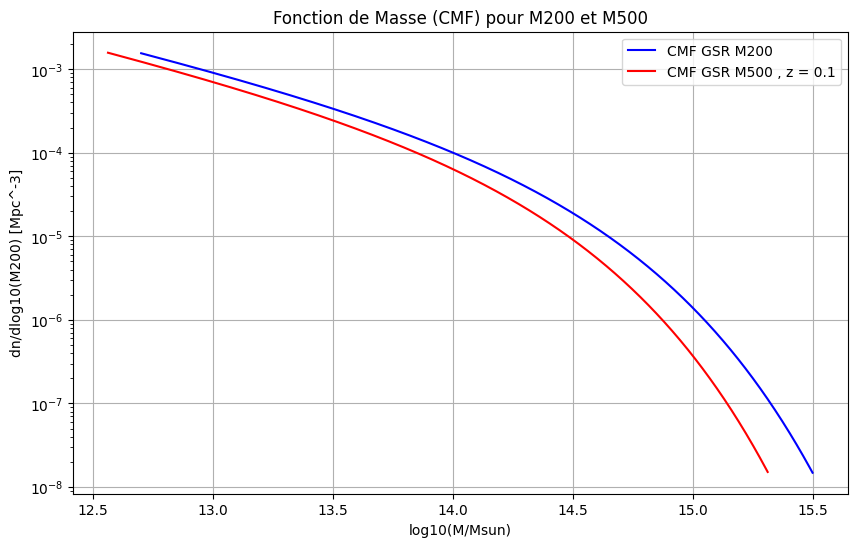

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(log10_M_Msun_M200, CMF_GSR_M200, label='CMF GSR M200', color='blue')
plt.plot(log10_M_Msun_M500, CMF_GSR_M500, label='CMF GSR M500 , z = 0.1', color='red')
plt.xlabel('log10(M/Msun)')
plt.ylabel('dn/dlog10(M200) [Mpc^-3]')
plt.title('Fonction de Masse (CMF) pour M200 et M500')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

Comparaison avec MSCUSS_500 et MeRASS1_500

In [80]:
# SCUSS

In [81]:
bornes_z_SCUSS = [0.05,0.65]
angular_area_SCUSS_deg2 = 3700 # Surface couverte par SCUSS/SDSS/unWISE en degrés carrés
volume_SCUSS = uf.Volume_survey(angular_area_SCUSS_deg2,bornes_z_SCUSS)

In [82]:
path_SCUSS = '../SCUSS_DESI/SCUSS_Gao_2020.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
table_SCUSS = uf.fits_to_dataframe(path_SCUSS)

zSCUSS_list = []
for idx, row in table_SCUSS.iterrows():
    if row[f'zsp'] == 0:
        zSCUSS_list.append(row[f'zph'])
    else:
        zSCUSS_list.append(row[f'zsp'])
table_SCUSS['z'] = zSCUSS_list

In [83]:
M500_SCUSS = np.log10(np.array(table_SCUSS['M500'])*1e14)
M500_SCUSS = M500_SCUSS[(M500_SCUSS > 12.7) & (M500_SCUSS < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

In [84]:
# Calculate histogram density using our utility function
bin_centers, counts, bin_width_SCUSS, n_SCUSS = uf.compute_histogram_density(
    data=M500_SCUSS,
    bins=100,
    volume=volume_SCUSS
)

print("Bin width:", bin_width_SCUSS)

Bin width: 0.024221519325980267


In [90]:
# eRASS1

In [91]:
bornes_z_eRASS1 = [0.03,1.32]
angular_area_eRASS1_deg2 = 13116 # Surface couverte par eRASS1/SDSS/unWISE en degrés carrés
volume_eRASS1 = uf.Volume_survey(angular_area_eRASS1_deg2,bornes_z_eRASS1)

In [92]:
path_eRASS1 = '../DESI_eRass/eRass_Bulbul_2024.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen

table_eRASS1 = uf.fits_to_dataframe(path_eRASS1)

nb_bins_z = 3 ; nb_bornes_z = nb_bins_z + 1 

M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
M500_eRASS1 = M500_eRASS1[(M500_eRASS1 > 12.2) & (M500_eRASS1 < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

C:\Users\ED282972\AppData\Local\Temp\ipykernel_26844\1295412310.py:7: RuntimeWarning: divide by zero encountered in log10
  M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun


In [93]:
table_eRASS1

,_Glon,_Glat,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,Exp,zBest,CR500,CTS500,F500,L500,KT,Mgas500,YX500,M500,Fgas500,R500
0,342.749444,-74.271282,0.021730,-38.624903,1eRASS J000005.2-383729,0.021730,-38.624903,94.8,0.3153,0.509,48.2,47.110,140.172,1.90,279.16,553.19,36.07,0.075,971
1,304.840929,-34.106230,0.089191,-82.831715,1eRASS J000021.4-824954,0.089191,-82.831715,184.2,0.0891,1.029,189.5,98.355,24.747,0.00,111.92,0.00,16.99,0.065,819
2,322.452374,-65.003240,0.129422,-50.151013,1eRASS J000031.0-500903,0.129422,-50.151013,117.3,0.0681,0.258,30.3,23.991,2.862,1.79,1.92,9.34,3.63,0.009,493
3,312.522359,-53.144799,0.132712,-63.025286,1eRASS J000031.8-630131,0.132712,-63.025286,139.6,0.2448,0.356,49.6,33.228,57.877,0.00,171.95,0.00,22.04,0.076,846
4,327.067385,-68.286558,0.189080,-46.394874,1eRASS J000045.3-462341,0.189080,-46.394874,109.5,0.0925,0.190,20.8,16.818,3.996,0.96,6.40,11.17,3.78,0.019,495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12242,314.228004,-55.350261,359.741833,-60.612333,1eRASS J235858.0-603644,359.741833,-60.612333,142.5,0.1052,3.556,506.8,337.065,97.721,0.00,358.95,0.00,38.67,0.093,1071
12243,317.972764,-60.279761,359.799123,-55.296727,1eRASS J235911.7-551748,359.799123,-55.296727,130.8,0.2137,0.121,15.8,11.402,15.028,0.00,5.59,0.00,8.15,0.008,614
12244,357.004155,-76.739217,359.864701,-34.306012,1eRASS J235927.5-341821,359.864701,-34.306012,87.5,0.1138,0.713,62.5,62.778,22.350,0.00,81.23,0.00,14.11,0.054,763
12245,330.823687,-70.028240,359.980381,-44.205215,1eRASS J235955.2-441218,359.980381,-44.205215,98.1,0.5797,0.136,13.4,12.342,165.113,0.00,41.31,0.00,25.92,0.020,785


In [94]:
bin_centers, counts_eRASS1, bin_width_eRASS1, n_eRASS1 = uf.compute_histogram_density(
    data=M500_eRASS1,
    bins=100,
    volume=volume_eRASS1
)

In [95]:
# Tracés

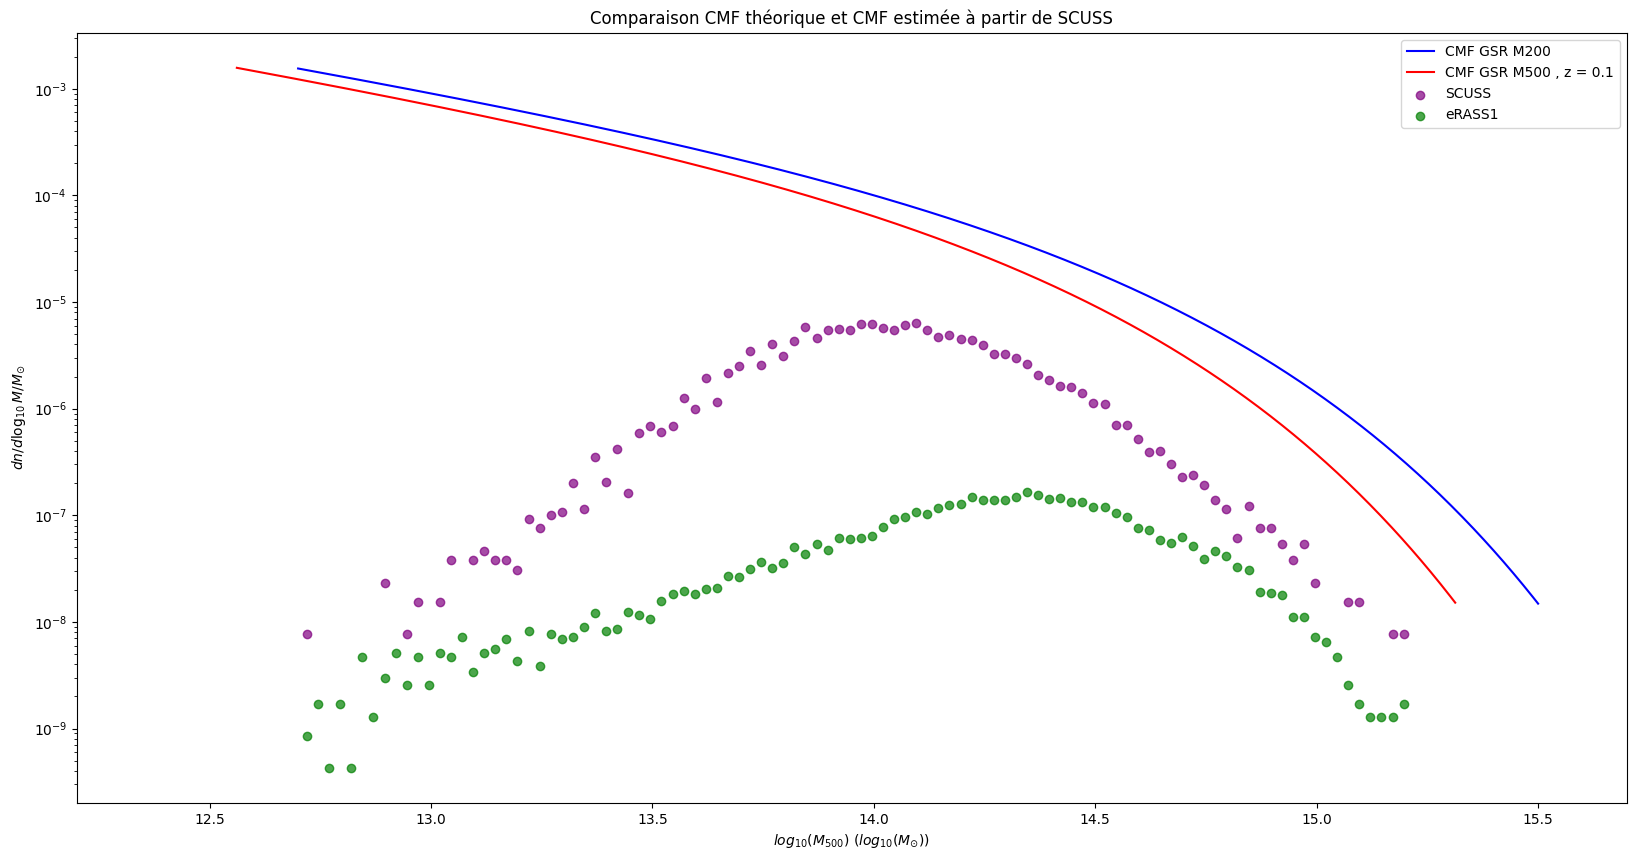

In [97]:
fig1 = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun_M200, CMF_GSR_M200, label='CMF GSR M200', color='blue')
plt.plot(log10_M_Msun_M500, CMF_GSR_M500, label='CMF GSR M500 , z = 0.1', color='red')


plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS', alpha=0.7)
plt.scatter(bin_centers, n_eRASS1, color='green', label='eRASS1', alpha=0.7)
plt.xlim(12.2, 15.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')

plt.legend()